In [ ]:
!pip install "dask[complete]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.7 MB/s eta 0:00:00


In [ ]:
from dask.distributed import Client
client = Client(n_workers=2, threads_per_worker=2, processes=True)
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:43079
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:38175'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46347'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44277 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44277
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:37914
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:43979 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:43979
INFO:distributed.core:Starting established connection to tcp://127

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 4,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43079,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44277,Total threads: 2
Dashboard: http://127.0.0.1:45597/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:38175,


In [ ]:
import dask
df = dask.datasets.timeseries()
df

,name,id,x,y
npartitions=30,,,,
2000-01-01,string,int64,float64,float64
2000-01-02,...,...,...,...
...,...,...,...,...
2000-01-30,...,...,...,...
2000-01-31,...,...,...,...


# Практическая работа 4.1. Анализ данных с помощью DASK

Практическая работа 4.1. Анализ данных с помощью DASK

**Задание.**

`4.1.1.` Настроить среду и рабочий каталог.

`4.1.2.` Загрузить данные.

`4.1.3.` Проверить качество данных (например, отсутствующие значения и выбросы).

`4.1.4.` Удалить столбцы (множество пропусков в значениях, бесполезные столбцы для анализа).

`4.1.1.` **Настроить среду и рабочий каталог.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/2026/etl

/content/drive/MyDrive/2026/etl


In [ ]:
ls

complex_dag.png  mydask.png
dask-expr.svg    Parking_Violations_Issued_-_Fiscal_Year_2017.csv


In [ ]:
# import libraries
import sys
import os

## import dask libraries
import dask.dataframe as dd
from dask.diagnostics import ProgressBar

# import libraries
import pandas as pd

In [ ]:
cwd = os.getcwd()

# print
print('', sys.executable)
print('', cwd)

 /usr/bin/python3
 /content/drive/MyDrive/2026/etl


`2.1.2.` **Загрузить данные.**

In [ ]:
from google.colab import files
files.upload()

KeyboardInterrupt: 

In [ ]:
## read data using DataFrame API
# Указываем явные типы для всех столбцов, где возможны пропуски или несоответствия
df = dd.read_csv(
    'Parking_Violations_Issued_-_Fiscal_Year_2017.csv',
    dtype={
        'House Number': 'object',
        'Time First Observed': 'object',
        'Date First Observed': 'float64',
        'Feet From Curb': 'float64',
        'Issuer Code': 'float64',
        'Issuer Precinct': 'float64',
        'Law Section': 'float64',
        'Vehicle Year': 'float64',
        'Violation Precinct': 'float64'
    }
)

df

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Time First Observed,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Intersecting Street,Date First Observed,Law Section,Sub Division,Violation Legal Code,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation
npartitions=1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,string,string,string,string,int64,string,string,string,int64,int64,int64,int64,float64,float64,float64,float64,string,string,string,string,string,string,string,string,string,float64,float64,string,string,string,string,string,string,float64,float64,string,float64,string,string,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [ ]:
df = pd.read_csv('Parking_Violations_Issued_-_Fiscal_Year_2017.csv', dtype={'House Number': 'object', 'Time First Observed': 'object'})
df

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation
0,5092469481,GZH7067,NY,PAS,07/10/2016,7,SUBN,TOYOT,V,0,...,GY,NaN,2001.0,NaN,0.0,NaN,FAILURE TO STOP AT RED LIGHT,NaN,NaN,NaN
1,5092451658,GZH7067,NY,PAS,07/08/2016,7,SUBN,TOYOT,V,0,...,GY,NaN,2001.0,NaN,0.0,NaN,FAILURE TO STOP AT RED LIGHT,NaN,NaN,NaN
2,4006265037,FZX9232,NY,PAS,08/23/2016,5,SUBN,FORD,V,0,...,BK,NaN,2004.0,NaN,0.0,NaN,BUS LANE VIOLATION,NaN,NaN,NaN
3,8478629828,66623ME,NY,COM,06/14/2017,47,REFG,MITSU,T,10610,...,WH,NaN,2007.0,NaN,0.0,04,47-Double PKG-Midtown,NaN,NaN,NaN
4,7868300310,37033JV,NY,COM,11/21/2016,69,DELV,INTER,T,10510,...,WHITE,NaN,2007.0,NaN,0.0,31 6,69-Failure to Disp Muni Recpt,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401103,7069502199,GHN8928,NY,PAS,08/08/2016,37,PICK,HONDA,T,15710,...,BK,NaN,2008.0,103-3055,0.0,44 7,37-Expired Muni Meter,NaN,NaN,NaN
401104,1384199639,14492JY,99,COM,07/29/2016,46,DELV,FRUEH,P,0,...,WH,0.0,2007.0,-,0.0,NaN,NaN,NaN,NaN,NaN
401105,4628768195,ENM5316,NY,PAS,12/23/2016,36,4DSD,HONDA,V,0,...,BL,NaN,2007.0,NaN,0.0,NaN,PHTO SCHOOL ZN SPEED VIOLATION,NaN,NaN,NaN
401106,8021230630,75675MD,NY,COM,09/28/2016,38,VAN,CHEVR,T,93250,...,WHITE,NaN,2008.0,NaN,0.0,210J,38-Failure to Display Muni Rec,NaN,NaN,NaN


Обратите внимание, что

- `metadata` отображаются в кадре вместо образца данных
синтаксис очень похож на API Pandas.

- `# partitions` — это количество разбиений, используемых для разделения основного набора данных. Оптимальное количество определяется планировщиком, который разделяет `DataFrame Pandas` на более мелкие фрагменты. В этом случае размер каждого раздела составляет ~64 МБ (т. е. размер набора данных/npartitions = 2 ГБ/33). Если у нас есть один рабочий процесс, Dask будет переключаться на каждый раздел по одному.

- `data types` сообщаются под каждым именем столбца (аналогично описанию метода в Pandas, однако выполняется путем случайной выборки, поскольку данные разбросаны по нескольким физическим машинам). Хорошей практикой является явное определение типов данных вместо того, чтобы полагаться на вывод Dask (в идеале хранить в двоичном формате).

- `Dask Name` сообщает имя группы обеспечения доступности баз данных (т.е. с задержкой).

- `# tasks` — это количество узлов в группе, которые обеспечивают доступность к данным. Вы можете представить задачу как функцию `Python`, и в этом случае каждая задача выполняет три задачи:

  1) чтение необработанных данных,

  2) разделение данных на соответствующие блоки,

  3) инициализация объекта `DataFrame`.

`2.1.3.` **Проверить качество данных (например, отсутствующие значения и выбросы).**

In [ ]:
# count missing values
missing_values = df.isnull().sum()
missing_values

Dask Series Structure:
npartitions=1
Date First Observed    int64
Violation Time           ...
Dask Name: sum, 5 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(3939f69)))).sum()

Обратите внимание на то, что:

Созданный объект `dask` представляет собой серию, содержащую метаданные, а синтаксис очень похож на `API Pandas`, обработка еще не завершена, вместо этого `Dask` подготовил `DAG`, сохраненный в переменной пропущенных значений (преимущество быстрого построения графика без необходимости ждать вычислений)

Количество задач увеличилось, поскольку были добавлены `2` задачи (т. е. проверка недостающих значений и суммы) для каждого из `32` разделов, а также окончательное добавление для агрегирования результатов по всем разделам, в общей сложности их - `4`.

In [ ]:
# calculate percent missing values
mysize = df.index.size
missing_count = ((missing_values / mysize) * 100)
missing_count

Dask Series Structure:
npartitions=1
Date First Observed    float64
Violation Time             ...
Dask Name: mul, 9 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(3939f69)))).sum() / Index(frame=ArrowStringConversion(frame=FromMapProjectable(3939f69))).size() * 100

Обратите внимание на то, что:

- созданный объект `dask` представляет собой серию, и вычисление еще не завершено.

- `df.index.size` — это объект `dask` `dask.dataframe.core.Scalar`. Вы не можете получить доступ к его значению/длине напрямую, как если бы вы это делали со списком (например, `len()`). Это противоречило бы всей идее `dask` (т.е. прочитать весь набор данных).

- `# tasks` количество задач увеличилось, так как были добавлены `2` задачи (т.е. деление и умножение).

-  `data type` изменен с `int64` на `float64`. Dask автоматически преобразовал его, если тип данных на выходе  не совпадает с входным после разделения.

In [ ]:
# запуск вычисления, используя метод подсчета
with ProgressBar():
  missing_count_percent = missing_count.compute()
missing_count_percent

,0
Summons Number,0.000000
Plate ID,0.006981
Registration State,0.000000
Plate Type,0.000000
Issue Date,0.000000
Violation Code,0.000000
Vehicle Body Type,0.373216
Vehicle Make,0.671141
Issuing Agency,0.000000
Street Code1,0.000000


Обратите внимание на то, что:

- метод `.compute()` необходим для запуска действий, встроенных в каждый узел группы обеспечения доступности баз данных.

- Результаты метода вычислений сохраняются в серии `Pandas`.

- `ProgressBar()` — это оболочка для отслеживания запущенных задач. Он показывает завершенную работу.

Видим, что не все столбцы являются неполными, и нам следует их удалить.

`4.1.4.` **Удалить столбцы (пропуски в значениях, бесполезные столбцы для анализа).**

In [ ]:
# 1. Получаем список столбцов для удаления
columns_to_drop = list(missing_count_percent[missing_count_percent > 60].index)
print("Столбцы на удаление:", columns_to_drop)

# 2. ОПТИМИЗАЦИЯ. Убираем .compute() и ProgressBar!
# Операция drop в Dask выполняется мгновенно и лениво.
# Она лишь записывает правило "не читать эти столбцы в будущем".
df_dropped = df.drop(columns=columns_to_drop)

# 3. Проверка результата
# Метод .head() автоматически вычислит только первые несколько строк
# из первого блока данных. Это займет доли секунды и почти не потребует RAM.
df_dropped.head()

Столбцы на удаление: ['Time First Observed', 'Intersecting Street', 'Violation Legal Code', 'Unregistered Vehicle?', 'Meter Number', 'No Standing or Stopping Violation', 'Hydrant Violation', 'Double Parking Violation']


,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Feet From Curb,Violation Post Code,Violation Description
0,5092469481,GZH7067,NY,PAS,07/10/2016,7,SUBN,TOYOT,V,0,...,1111.0,D,<NA>,<NA>,<NA>,GY,2001.0,0.0,<NA>,FAILURE TO STOP AT RED LIGHT
1,5092451658,GZH7067,NY,PAS,07/08/2016,7,SUBN,TOYOT,V,0,...,1111.0,D,<NA>,<NA>,<NA>,GY,2001.0,0.0,<NA>,FAILURE TO STOP AT RED LIGHT
2,4006265037,FZX9232,NY,PAS,08/23/2016,5,SUBN,FORD,V,0,...,1111.0,C,<NA>,<NA>,<NA>,BK,2004.0,0.0,<NA>,BUS LANE VIOLATION
3,8478629828,66623ME,NY,COM,06/14/2017,47,REFG,MITSU,T,10610,...,408.0,l2,Y,0700A,0700P,WH,2007.0,0.0,04,47-Double PKG-Midtown
4,7868300310,37033JV,NY,COM,11/21/2016,69,DELV,INTER,T,10510,...,408.0,h1,Y,0700A,0700P,WHITE,2007.0,0.0,31 6,69-Failure to Disp Muni Recpt


In [ ]:
import dask.dataframe as dd
from dask.diagnostics import ProgressBar

# Define the corrected dtypes as suggested by the traceback
corrected_dtypes = {
    'House Number': 'object',
    'Time First Observed': 'object',
    'Date First Observed': 'float64',
    'Feet From Curb': 'float64',
    'Issuer Code': 'float64',
    'Issuer Precinct': 'float64',
    'Law Section': 'float64',
    'Vehicle Year': 'float64',
    'Violation Precinct': 'float64'
}

# Re-read the data with corrected dtypes
df = dd.read_csv('Parking_Violations_Issued_-_Fiscal_Year_2017.csv', dtype=corrected_dtypes)

# Re-calculate missing values and missing percentage
missing_values = df.isnull().sum()
mysize = df.index.size
missing_count = ((missing_values / mysize) * 100)

# Compute the missing count percentage
with ProgressBar():
  missing_count_percent = missing_count.compute()

missing_count_percent

,0
Summons Number,0.000000
Plate ID,0.006981
Registration State,0.000000
Plate Type,0.000000
Issue Date,0.000000
Violation Code,0.000000
Vehicle Body Type,0.373216
Vehicle Make,0.671141
Issuing Agency,0.000000
Street Code1,0.000000


Обратите внимание на то, что:

- использовать `Pandas Series` для удаления столбцов в `Dask DataFrame`, поскольку каждый раздел является `Pandas DataFrame`.

- В случае, если серия доступна для всех потоков, в кластере она будет сериализована и широковещательно передана всем рабочим узлам.

# Практическая работа 4.2. Визуализация ориентированных ациклических графов (DAG)

- `DASK` использует библиотеку `Graviz` для создания визуального представления групп `DAG`, созданных планировщиком.

- и спользуйте метод `.visualize()` для проверки групп `DAG DataFrames`, `Series`, `Bag` и массивов.

Для упрощения будем использовать объект `Dask Delayed` вместо `DataFrames`, поскольку они становятся довольно большими и их трудно визуализировать.

- `Delayed` — это конструктор, который позволяет обертывать функции и создавать объекты `Dask Delayed`, эквивалентные узлу в `DAG`. Объединяя захваченные объекты, создаем группу доступа к данным.

Ниже приведены два примера: в первом  `DAG` только с одним узлом и зависимостями, а во втором  - `DAG` с несколькими узлами и зависимостями.

Практическая работа 4.2. Визуализация ориентированных ациклических графов (DAG)

**Задание.**

`4.2.1.` Визуализировать `DAG` с одним узлом и зависимостями.

`4.2.1.` Визуализировать `DAG` с более чем одним узлом и зависимостями.



`4.1.1.` **Визуализировать `DAG` с одним узлом и зависимостями.**

In [ ]:
# import library
import dask.delayed as delayed

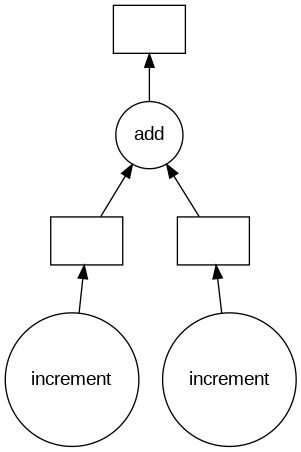

In [ ]:
def increment(i):
    return i + 1

def add(x, y):
    return x + y

# функции переноса внутри отложенного объекта и цепочки
x = delayed(increment)(1)
y = delayed(increment)(2)
z = delayed(add)(x, y)

# visualize the DAG
z.visualize()

In [ ]:
# show the result
z.compute()

5

Обратите внимание на то, что:

- Чтобы построить узел, в функцию передали захваченный объект, а затем передали аргументы этой функции. Можно использовать декораторы.

- Круги указывают на функцию и вычисления, а квадраты — промежуточный или конечный результат.

- Входящие стрелки представляют зависимости. Функция `increment` не имеет никаких зависимостей, а функция `add` — две. Таким образом, функция `add`  должна ждать, пока не будут вычислены объекты `x` и `y`.

- Функции без зависимостей могут вычисляться независимо, и каждой из них можно назначить `workera`.

- Используйте метод `.visualize()` на последнем узле с зависимостями.

- `Dask` не расчитывает `DAG`. Используйте метод `.compute()` на последнем узле, чтобы увидеть результат.

`4.2.2.` **Визуализировать `DAG` с более чем одним узлом и зависимостями.**

построить более сложную группу `DAG` с двумя уровнями:

- `Layer1` создается путем циклического перебора списка данных  в ​`​dask` . Этот слой объединяет ранее созданное приращение функции со значениями в списке, а затем использует встроенное суммирование функции для объединения результатов;

- `Layer2` построен циклически для каждого объекта, созданного в `Layer1`.

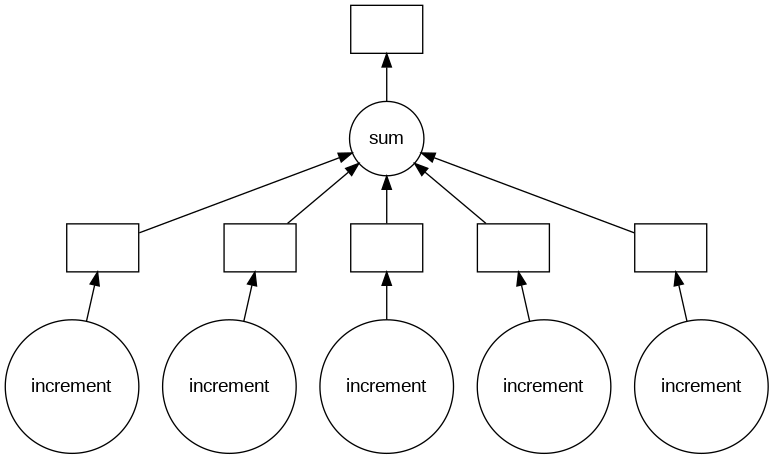

In [ ]:
data = [1, 2, 3, 4, 5]

# compile first layer and visualize
layer1 = [delayed(increment)(i) for i in data]
total1 = delayed(sum)(layer1)
total1.visualize()

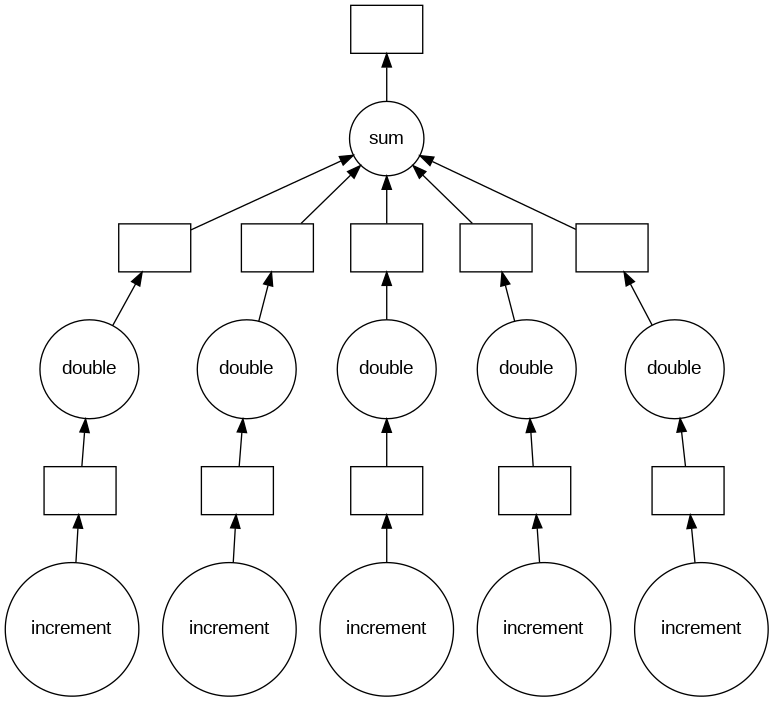

In [ ]:
def double(x):
    return x * 2

# compile second layer and visualize
layer2 = [delayed(double)(j) for j in layer1]
total2 = delayed(sum)(layer2)#.persist()
total2.visualize()

In [ ]:
z = total2.compute()
z

40

Обратите внимание на то, что:

- построение через использование функции,

- используем `.persist()`, и результат будет представлен на графике в виде прямоугольника.

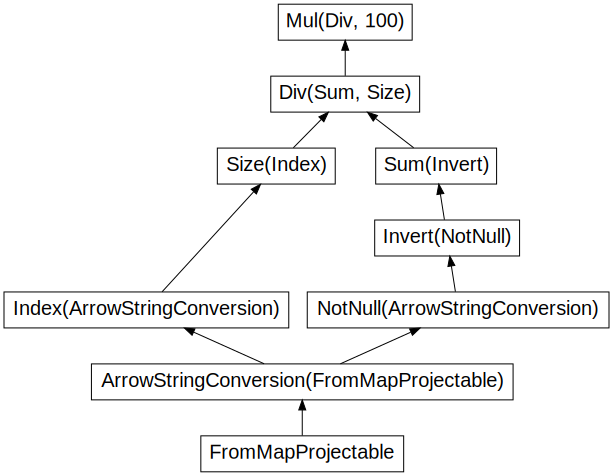

In [ ]:
# visualize DAGs built from the DataFrame
missing_count.visualize()

# Самостоятельная работа. Анализ и обработка больших данных с Dask


**Цель работы:** закрепить навыки построения базовых ETL-конвейеров (Extract, Transform, Load) для обработки больших массивов данных средствами библиотеки Dask, освоить принципы ленивых (lazy) вычислений, управление памятью и визуализацию графов задач (DAG).

---
### Исходные данные
Каталог датасетов расположен по ссылке: [Yandex Disk](https://disk.yandex.ru/d/fbPE3VNKYocd7g)

### Описание задания
Вам необходимо построить Dask-пайплайн, строго следуя концепции ETL, избегая переполнения оперативной памяти:

1. **Extract (Извлечение данных)**
    * Настройте локальный кластер `Dask Client` с оптимальными параметрами для вашей среды (без жестких ограничений памяти, чтобы избежать ошибки `KilledWorker`).
    * Подключите директорию с данными и считайте ваш вариант датасета (см. таблицу ниже), используя `dask.dataframe.read_csv` (при необходимости распакуйте архив).

2. **Transform (Трансформация и очистка)**
    * Проведите профилирование качества данных: вычислите процент пропущенных значений для каждого столбца. Метод `.compute()` используйте *только* для получения финального небольшого результата (списка процентов).
    * На основе полученной статистики сформируйте список столбцов, в которых более 60% пропусков.
    * «Лениво» (без вызова `compute()`) удалите эти столбцы из основного Dask DataFrame.

3. **Load (Загрузка результатов)**
    * Чтобы завершить ETL-цикл, сохраните очищенный Dask DataFrame обратно на диск в виде набора файлов.
    * Используйте функцию `.to_parquet('cleaned_data.parquet')` или `.to_csv('cleaned_data-*.csv')`. Это позволит Dask обработать и сохранить огромный массив данных по частям, не загружая его целиком в RAM.

4. **Визуализация графов вычислений (DAG)**
    * Используя декоратор или функцию `dask.delayed`, создайте логику из нескольких простых python-функций (например, фильтрация, агрегация, математические вычисления).
    * Постройте простой ориентированный ациклический граф (DAG) с одним узлом и его зависимостями. Визуализируйте его методом `.visualize()`.
    * Постройте сложный двухуровневый DAG (используя списковые включения или циклы для имитации map-reduce операций). Визуализируйте результат.

Каталог датасетов [тут](https://disk.yandex.ru/d/fbPE3VNKYocd7g). Прямая ссылка https://disk.yandex.ru/d/fbPE3VNKYocd7g.




### Таблица вариантов

Выберите ваш набор данных в зависимости от номера варианта:

| Вариант | Имя файла (Датасет для ETL) |
| :---: | :--- |
| **1, 7, 13, 19, 25** | `Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv` |
| **2, 8, 14, 20** | `Parking_Violations_Issued_-_Fiscal_Year_2015.csv` |
| **3, 9, 15, 21** | `Parking_Violations_Issued_-_Fiscal_Year_2016.csv` |
| **4, 10, 16, 22** | `Parking_Violations_Issued_-_Fiscal_Year_2017.csv` |
| **5, 11, 17, 23** | `UK Property Price official data 1995-202304.zip` |
| **6, 12, 18, 24** | `Austin, TX House Listings.zip` |

In [52]:
# Подготовка окружения
!pip install "dask[complete]" graphviz

In [53]:
import dask.dataframe as dd
import dask.delayed as delayed
from dask.distributed import Client
from dask.diagnostics import ProgressBar

# Инициализация клиента Dask (Оптимизированные настройки без жесткого лимита памяти)
client = Client(n_workers=2, threads_per_worker=2, processes=True)
client

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39915 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:43381
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:39915/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:36071'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40075'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:40391 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:40391
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:46244
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:33561 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:33561
IN

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:39915/status,
Dashboard: http://127.0.0.1:39915/status,Workers: 2
Total threads: 4,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43381,Workers: 0
Dashboard: http://127.0.0.1:39915/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40391,Total threads: 2
Dashboard: http://127.0.0.1:41553/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:36071,


#### Шаг 1. Extract (Извлечение данных)

In [54]:
# Ваш код здесь (укажите путь к вашему варианту файла)
# df = dd.read_csv('путь_к_вашему_файлу.csv')

# Указываем путь к файлу (предполагается, что файл находится в текущей директории)
file_path = 'Parking_Violations_Issued_-_Fiscal_Year_2017.csv'

# Явно задаём типы для проблемных столбцов, чтобы избежать ошибки Mismatched dtypes
df = dd.read_csv(
    file_path,
    dtype={
        'House Number': 'object',
        'Time First Observed': 'object',
        'Date First Observed': 'float64',
        'Feet From Curb': 'float64',
        'Issuer Code': 'float64',
        'Issuer Precinct': 'float64',
        'Law Section': 'float64',
        'Vehicle Year': 'float64',
        'Violation Precinct': 'float64'
    }
)

# Просмотр метаданных (лениво)
df

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Time First Observed,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Intersecting Street,Date First Observed,Law Section,Sub Division,Violation Legal Code,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation
npartitions=1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,string,string,string,string,int64,string,string,string,int64,int64,int64,int64,float64,float64,float64,float64,string,string,string,string,string,string,string,string,string,float64,float64,string,string,string,string,string,string,float64,float64,string,float64,string,string,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


#### Шаг 2. Transform (Трансформация и очистка данных)

In [55]:
# 1. Профилирование пропусков
missing_values = df.isnull().sum()
total_rows = df.index.size
missing_percent = ((missing_values / total_rows) * 100)

# Вычисляем проценты пропусков (единственный вызов compute() для небольшого результата)
with ProgressBar():
    missing_percent_computed = missing_percent.compute()

print("Процент пропусков по столбцам:")
print(missing_percent_computed)

# 2. Удаление разреженных столбцов (лениво!)
columns_to_drop = list(missing_percent_computed[missing_percent_computed > 60].index)
print("Столбцы для удаления:", columns_to_drop)

df_cleaned = df.drop(columns=columns_to_drop)

# Проверка результата (первые 5 строк, вычисляется только небольшой фрагмент)
df_cleaned.head()

Процент пропусков по столбцам:
Summons Number                         0.000000
Plate ID                               0.006981
Registration State                     0.000000
Plate Type                             0.000000
Issue Date                             0.000000
Violation Code                         0.000000
Vehicle Body Type                      0.373216
Vehicle Make                           0.671141
Issuing Agency                         0.000000
Street Code1                           0.000000
Street Code2                           0.000000
Street Code3                           0.000000
Vehicle Expiration Date                0.000000
Violation Location                    18.484797
Violation Precinct                     0.000249
Issuer Precinct                        0.000249
Issuer Code                            0.000249
Issuer Command                        18.392303
Issuer Squad                          18.401528
Violation Time                         0.000748
Time Firs

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Feet From Curb,Violation Post Code,Violation Description
0,5092469481,GZH7067,NY,PAS,07/10/2016,7,SUBN,TOYOT,V,0,...,1111.0,D,<NA>,<NA>,<NA>,GY,2001.0,0.0,<NA>,FAILURE TO STOP AT RED LIGHT
1,5092451658,GZH7067,NY,PAS,07/08/2016,7,SUBN,TOYOT,V,0,...,1111.0,D,<NA>,<NA>,<NA>,GY,2001.0,0.0,<NA>,FAILURE TO STOP AT RED LIGHT
2,4006265037,FZX9232,NY,PAS,08/23/2016,5,SUBN,FORD,V,0,...,1111.0,C,<NA>,<NA>,<NA>,BK,2004.0,0.0,<NA>,BUS LANE VIOLATION
3,8478629828,66623ME,NY,COM,06/14/2017,47,REFG,MITSU,T,10610,...,408.0,l2,Y,0700A,0700P,WH,2007.0,0.0,04,47-Double PKG-Midtown
4,7868300310,37033JV,NY,COM,11/21/2016,69,DELV,INTER,T,10510,...,408.0,h1,Y,0700A,0700P,WHITE,2007.0,0.0,31 6,69-Failure to Disp Muni Recpt


#### Шаг 3. Load (Сохранение результатов пайплайна)

In [56]:
# Рекомендуется сохранение в parquet для повышения скорости и сжатия
# df_dropped.to_parquet('cleaned_dataset.parquet', engine='pyarrow')
# Сохранение очищенного датасета в формате Parquet
df_cleaned.to_parquet('cleaned_parking_violations.parquet', engine='pyarrow')
print("Данные сохранены в cleaned_parking_violations.parquet")


Данные сохранены в cleaned_parking_violations.parquet


#### Шаг 4. Визуализация направленных ациклических графов (DAG)

In [57]:
# А) Простой DAG
# Определяем простые функции
def increment(i):
    return i + 1

def add(x, y):
    return x + y

# Создаём отложенные объекты
x = delayed(increment)(1)
y = delayed(increment)(2)
z = delayed(add)(x, y)

# Визуализация графа
z.visualize(filename='simple_dag.png')
print("Граф simple_dag.png сохранён")

# Вычисление результата
print("Результат вычисления:", z.compute())

Граф simple_dag.png сохранён
Результат вычисления: 5


In [58]:
# Б) Многоуровневый DAG
data = [1, 2, 3, 4, 5]

# Слой 1: инкремент каждого элемента
layer1 = [delayed(increment)(i) for i in data]

def double(x):
    return x * 2

# Слой 2: удвоение результатов из слоя 1
layer2 = [delayed(double)(j) for j in layer1]

# Финальная агрегация
total = delayed(sum)(layer2)

# Визуализация полного графа
total.visualize(filename='complex_dag.png')
print("Граф complex_dag.png сохранён")

# Вычисление результата
print("Итоговый результат:", total.compute())

Граф complex_dag.png сохранён
Итоговый результат: 40


# Визуальная аналитика

In [59]:
!pip install seaborn matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Для отображения графиков в Colab
%matplotlib inline

In [60]:
# ==================== Аналитика и визуализация ====================

# 1. Преобразуем Issue Date в datetime (если столбец существует)
if 'Issue Date' in df_cleaned.columns:
    # Ленивое преобразование (добавится в граф вычислений)
    df_cleaned = df_cleaned.assign(Issue_Date=dd.to_datetime(df_cleaned['Issue Date'], format='%m/%d/%Y'))
else:
    print("Столбец 'Issue Date' не найден.")


/tmp/ipykernel_686/1982973598.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_violations.values, y=top_violations.index, palette='viridis')


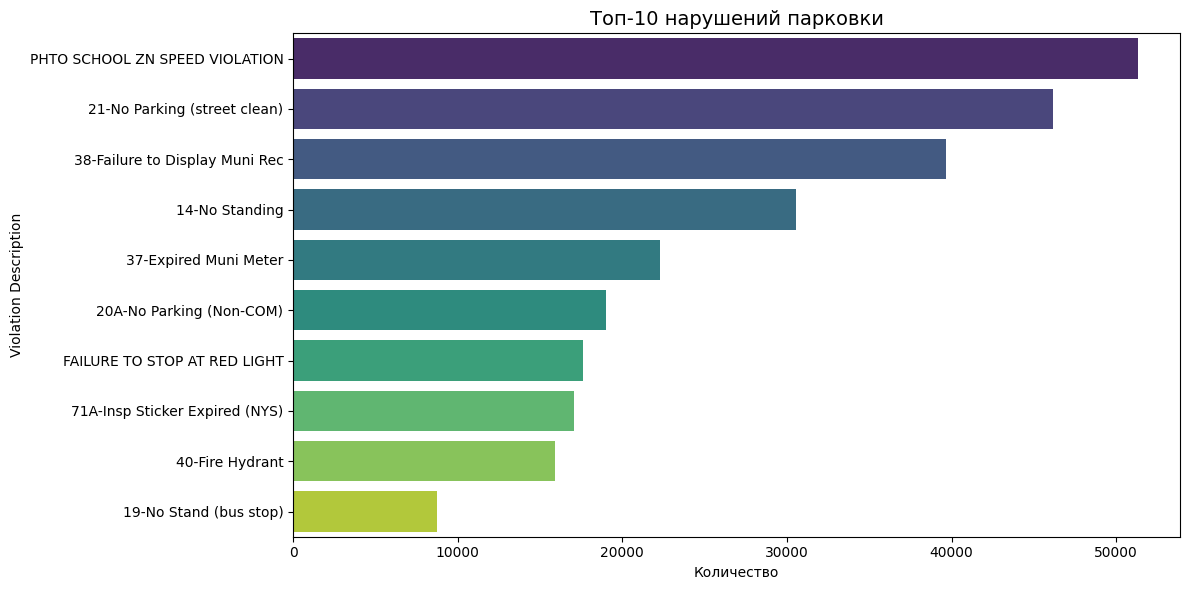

In [61]:

# 2. Топ-10 нарушений (Violation Description)
if 'Violation Description' in df_cleaned.columns:
    top_violations = (df_cleaned['Violation Description']
                      .value_counts()
                      .nlargest(10)
                      .compute())
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_violations.values, y=top_violations.index, palette='viridis')
    plt.title('Топ-10 нарушений парковки', fontsize=14)
    plt.xlabel('Количество')
    plt.tight_layout()
    plt.savefig('top_violations.png')
    plt.show()
else:
    print("Столбец 'Violation Description' отсутствует.")



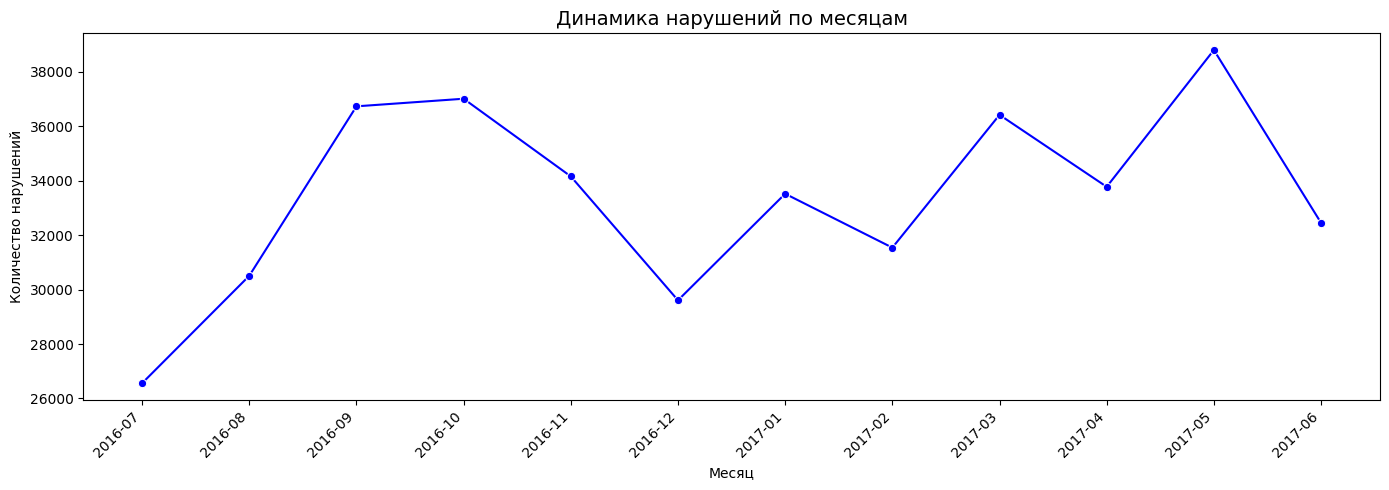

In [62]:
# 3. Динамика нарушений по месяцам (если есть Issue_Date)
if 'Issue_Date' in df_cleaned.columns:
    # Группируем по году и месяцу
    monthly_counts = (df_cleaned.groupby(df_cleaned['Issue_Date'].dt.to_period('M'))
                      .size()
                      .compute()
                      .reset_index(name='count'))

    # Преобразуем период в строку для отображения
    monthly_counts['month'] = monthly_counts['Issue_Date'].astype(str)

    plt.figure(figsize=(14, 5))
    sns.lineplot(data=monthly_counts, x='month', y='count', marker='o', color='b')
    plt.title('Динамика нарушений по месяцам', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Месяц')
    plt.ylabel('Количество нарушений')
    plt.tight_layout()
    plt.savefig('monthly_trend.png')
    plt.show()
else:
    print("Столбец 'Issue_Date' отсутствует.")


/tmp/ipykernel_686/720897966.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=body_counts.values, y=body_counts.index, palette='rocket')


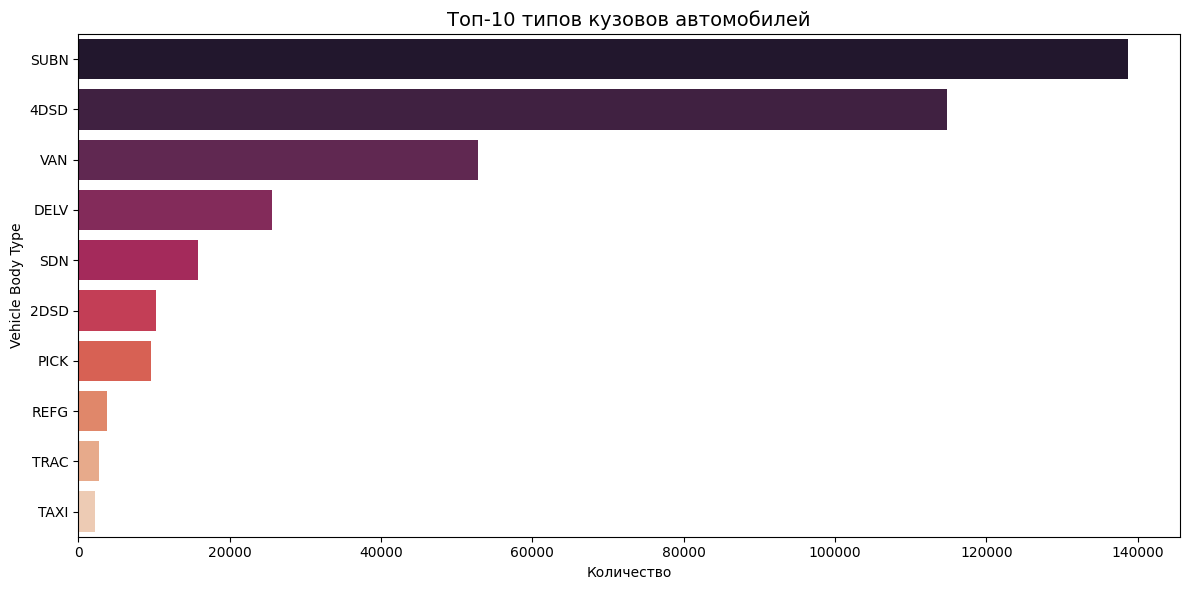

In [63]:

# 4. Распределение типов кузовов (Vehicle Body Type)
if 'Vehicle Body Type' in df_cleaned.columns:
    body_counts = (df_cleaned['Vehicle Body Type']
                   .value_counts()
                   .nlargest(10)
                   .compute())

    plt.figure(figsize=(12, 6))
    sns.barplot(x=body_counts.values, y=body_counts.index, palette='rocket')
    plt.title('Топ-10 типов кузовов автомобилей', fontsize=14)
    plt.xlabel('Количество')
    plt.tight_layout()
    plt.savefig('body_types.png')
    plt.show()
else:
    print("Столбец 'Vehicle Body Type' отсутствует.")



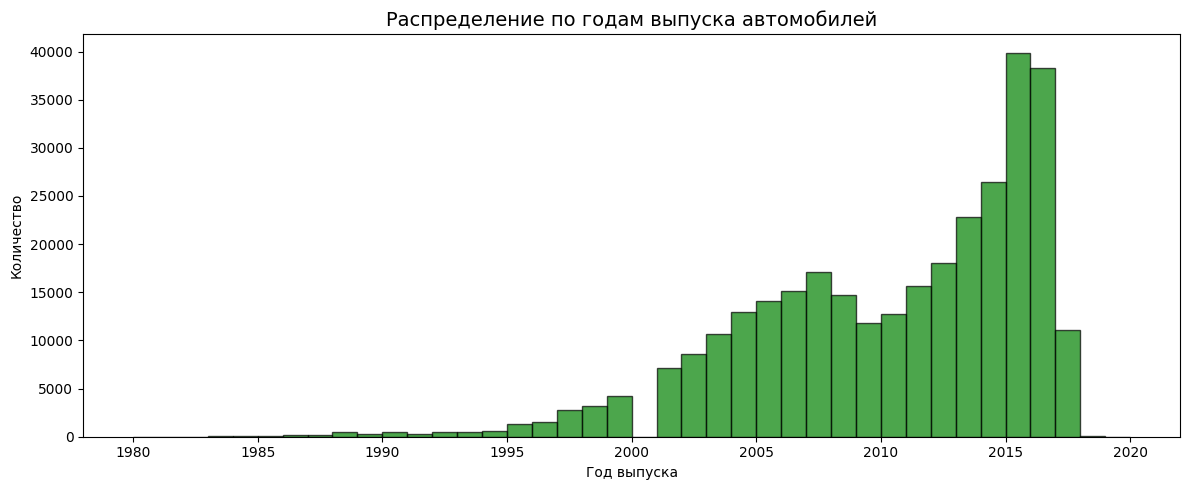

In [66]:
# 5. Гистограмма по годам выпуска автомобилей (Vehicle Year)
if 'Vehicle Year' in df_cleaned.columns:
    # Убираем пропуски и ограничим разумным диапазоном (например, 1980-2020)
    vehicle_years = (df_cleaned['Vehicle Year']
                     .dropna()
                     .loc[(df_cleaned['Vehicle Year'] >= 1980) & (df_cleaned['Vehicle Year'] <= 2020)]
                     .compute())

    plt.figure(figsize=(12, 5))
    plt.hist(vehicle_years, bins=40, edgecolor='black', alpha=0.7, color='green')
    plt.title('Распределение по годам выпуска автомобилей', fontsize=14)
    plt.xlabel('Год выпуска')
    plt.ylabel('Количество')
    plt.tight_layout()
    plt.savefig('vehicle_years.png')
    plt.show()
else:
    print("Столбец 'Vehicle Year' отсутствует.")



/tmp/ipykernel_686/4178626814.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=color_counts.values, y=color_counts.index, palette='viridis')


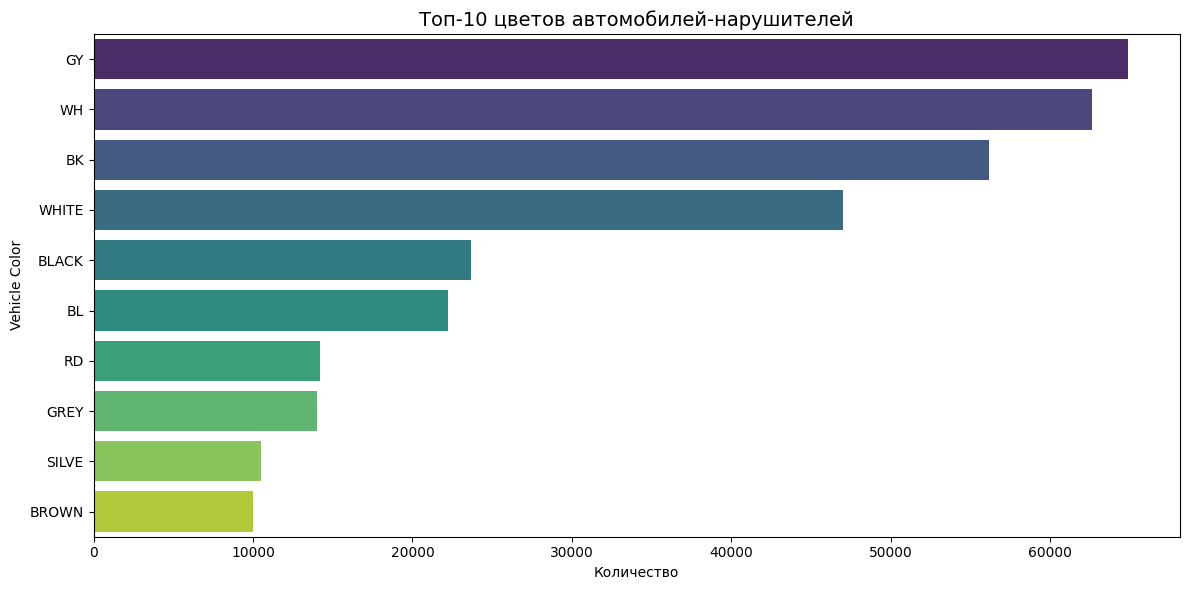

In [67]:
# 6. Нарушения по цветам автомобилей (Vehicle Color)
if 'Vehicle Color' in df_cleaned.columns:
    color_counts = (df_cleaned['Vehicle Color']
                    .value_counts()
                    .nlargest(10)
                    .compute())

    plt.figure(figsize=(12, 6))
    sns.barplot(x=color_counts.values, y=color_counts.index, palette='viridis')
    plt.title('Топ-10 цветов автомобилей-нарушителей', fontsize=14)
    plt.xlabel('Количество')
    plt.tight_layout()
    plt.savefig('vehicle_colors.png')
    plt.show()
else:
    print("Столбец 'Vehicle Color' отсутствует.")
